# Deep Learning Course Project: Chest X-Ray Classification
**Students:** Lihi Skif, Liel Yaakobov

**IDs:** 322235888, 322366311

**Task:** Classifying X-ray images into 3 categories: Normal, Bacterial Pneumonia, and Viral Pneumonia.

**Imports and Environment Setup**

In [ ]:
# SETUP: Importing essential libraries for deep learning, data manipulation, and visualization
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
from PIL import Image

# DEVICE CHECK: Setting up the computation device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Current device: {device}")

Current device: cuda


In [ ]:
import subprocess

MODEL_FILE_IDS = {
    'model_A_cnn.keras': '',
    'model_b_finetuned.keras': '',
    'model_C_patch_rnn.keras': '',
    'best_model.keras': '',
    'class_indices.json': '',
}

LOCAL_DIR = '/content/dl_project_weights' if os.path.exists('/content') else './dl_project_weights'
os.makedirs(LOCAL_DIR, exist_ok=True)
BASE_SAVE_DIR = LOCAL_DIR

try:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_path = '/content/drive/MyDrive/dl_project_weights'
    if os.path.exists(os.path.join(drive_path, 'model_A_cnn.keras')):
        BASE_SAVE_DIR = drive_path
        print("Using Drive:", BASE_SAVE_DIR)
    else:
        os.makedirs(drive_path, exist_ok=True)
        BASE_SAVE_DIR = drive_path
        print("Drive mounted:", BASE_SAVE_DIR)
except Exception:
    pass

if not os.path.exists(os.path.join(BASE_SAVE_DIR, 'model_A_cnn.keras')):
    for fname, fid in MODEL_FILE_IDS.items():
        if not fid:
            continue
        path = os.path.join(LOCAL_DIR, fname)
        if not os.path.exists(path):
            print(f"Downloading {fname}...")
            subprocess.run(['gdown', fid, '-O', path], check=False, capture_output=True)
    if os.path.exists(os.path.join(LOCAL_DIR, 'model_A_cnn.keras')):
        BASE_SAVE_DIR = LOCAL_DIR
        print("Models downloaded.")

print("Base save directory:", BASE_SAVE_DIR)


**Downloading Dataset from Kaggles**



In [ ]:
# STEP 2: DOWNLOAD DATASET USING GDOWN
import os
import zipfile

file_id = '1oFV6HOu93q02uENCwrY2aYgPCwMAfvsh'
output_filename = 'chest_xray_data.zip'

if not os.path.exists(output_filename):
    print("Starting download with gdown...")
    !gdown --id {file_id} -O {output_filename}
else:
    print(f"File {output_filename} already exists, skipping download.")

# STEP 3: EXTRACTION
extract_dir = 'chest_xray_files'
if not os.path.exists(extract_dir):
    print("Extracting files...")
    with zipfile.ZipFile(output_filename, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction complete! Your data is ready.")
else:
    print("Files already extracted.")

Starting download with gdown...
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1oFV6HOu93q02uENCwrY2aYgPCwMAfvsh
From (redirected): https://drive.google.com/uc?id=1oFV6HOu93q02uENCwrY2aYgPCwMAfvsh&confirm=t&uuid=65a8921d-aaef-42df-9c35-e1c5acf070f2
To: /content/chest_xray_data.zip
100% 2.46G/2.46G [00:35<00:00, 69.4MB/s]
Extracting files...
Extraction complete! Your data is ready.


**Data Preprocessing - Organizing Dataset into Three Classes**

**Categories:** Normal, Bacterial Pneumonia, and Viral Pneumonia

In [ ]:
import os
import shutil

# base path to the extracted dataset – update if you change the location
base_path = 'chest_xray_files/chest_xray'
output_path = 'final_dataset'

def organize_3_classes(src, dest):
    splits = ['train', 'test', 'val']
    categories = ['NORMAL', 'BACTERIAL', 'VIRAL']

    for split in splits:
        # Create the new folders
        for cat in categories:
            os.makedirs(os.path.join(dest, split, cat), exist_ok=True)

        # 1. Move Normal images
        normal_src = os.path.join(src, split, 'NORMAL')
        if os.path.exists(normal_src):
            for img in os.listdir(normal_src):
                shutil.copy(os.path.join(normal_src, img), os.path.join(dest, split, 'NORMAL', img))

        # 2. Split Pneumonia into Bacterial and Viral
        pneu_src = os.path.join(src, split, 'PNEUMONIA')
        if os.path.exists(pneu_src):
            for img in os.listdir(pneu_src):
                # We check the filename to decide the category
                if 'bacteria' in img.lower():
                    shutil.copy(os.path.join(pneu_src, img), os.path.join(dest, split, 'BACTERIAL', img))
                elif 'virus' in img.lower():
                    shutil.copy(os.path.join(pneu_src, img), os.path.join(dest, split, 'VIRAL', img))

# Run it
organize_3_classes(base_path, output_path)
print("Done! Check the 'final_dataset' folder in your files tab.")

Done! Check the 'final_dataset' folder in your files tab.


**Data Augmentation and Data Loading**

**Goal**: Build a consistent input pipeline for training and evaluation.

In this cell, we:

1. Resize all images to 224×224 (required input size for EfficientNetB0 and used across all models).

2. Preprocess/Normalize images using preprocess_input (the same normalization EfficientNet expects).

3. Augment the training set only (small rotations, zoom, and horizontal flips) to improve generalization and reduce overfitting.

4. Split Train → Train/Validation using validation_split=0.2 to create a validation set without touching the original test set.

5. Create generators that load images in batches of 32, with shuffle=False for validation/test to ensure stable and repeatable evaluation.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# TRAIN: augmentation + split
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

# VAL: NO augmentation (only preprocess) + same split
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

# TEST: NO augmentation
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    'final_dataset/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    'final_dataset/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    'final_dataset/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("TRAIN class_indices:", train_generator.class_indices)
print("VAL   class_indices:", val_generator.class_indices)
print("TEST  class_indices:", test_generator.class_indices)
print("Train/Val/Test samples:", train_generator.samples, val_generator.samples, test_generator.samples)

Found 4173 images belonging to 3 classes.
Found 1043 images belonging to 3 classes.
Found 624 images belonging to 3 classes.
TRAIN class_indices: {'BACTERIAL': 0, 'NORMAL': 1, 'VIRAL': 2}
VAL   class_indices: {'BACTERIAL': 0, 'NORMAL': 1, 'VIRAL': 2}
TEST  class_indices: {'BACTERIAL': 0, 'NORMAL': 1, 'VIRAL': 2}
Train/Val/Test samples: 4173 1043 624


**Custom Deep Convolutional Neural Network**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

# =========================
# CNN from scratch (same architecture)
# =========================
inputs = layers.Input(shape=(224,224,3))

x = layers.Conv2D(32, 3, padding="same")(inputs)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(256, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D()(x)

x = layers.Dropout(0.3)(x)
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(3, activation="softmax")(x)

model_a = models.Model(inputs, outputs, name="CNN_from_scratch")

# =========================
# Compile (fixed LR)
# =========================
LR = 3e-4
EPOCHS = 20

model_a.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# =========================
# Train (NO callbacks, NO class_weight) or load existing
# =========================
model_a_path = os.path.join(BASE_SAVE_DIR, "model_A_cnn.keras")
if os.path.exists(model_a_path):
    print(f"Loading Model A from {model_a_path}")
    model_a = tf.keras.models.load_model(model_a_path)
    history = None
else:
    history = model_a.fit(
        train_generator,
        epochs=EPOCHS,
        validation_data=val_generator
    )
    model_a.save(model_a_path)
    print(f"Saved Model A to {model_a_path}")

# =========================
# Best VAL print
# =========================
best_epoch = int(np.argmax(history.history["val_accuracy"]))
best_val_acc = float(history.history["val_accuracy"][best_epoch])
best_val_loss = float(history.history["val_loss"][best_epoch])

print("\n================ MODEL A (CNN SCRATCH) SUMMARY ================\n")
print(f"Fixed learning rate: {LR}")
print(f"Trained epochs: {EPOCHS}")
print(f"Best epoch (by val_accuracy): {best_epoch + 1}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Validation Loss at Best Epoch: {best_val_loss:.4f}")
print("\n===============================================================\n")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 721ms/step - accuracy: 0.6124 - loss: 0.9158 - val_accuracy: 0.3298 - val_loss: 1.3266
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 86s 655ms/step - accuracy: 0.7227 - loss: 0.6932 - val_accuracy: 0.4899 - val_loss: 1.6317
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 85s 648ms/step - accuracy: 0.7360 - loss: 0.6346 - val_accuracy: 0.4430 - val_loss: 1.7458
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 85s 652ms/step - accuracy: 0.7451 - loss: 0.6316 - val_accuracy: 0.5216 - val_loss: 3.3332
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 86s 654ms/step - accuracy: 0.7558 - loss: 0.5831 - val_accuracy: 0.2617 - val_loss: 8.7479
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 86s 654ms/step - accuracy: 0.7625 - loss: 0.6003 - val_accuracy: 0.5312 - val_loss: 1.9692
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 86s 660ms/step - accuracy: 0.7632 - loss: 0.5648 - val_accuracy: 0.2800 - val_loss: 5.5249
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 86s 654ms/step - accuracy: 0.7783 - loss: 

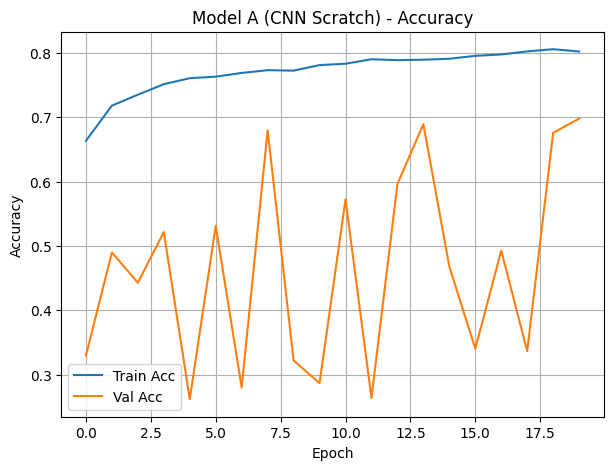

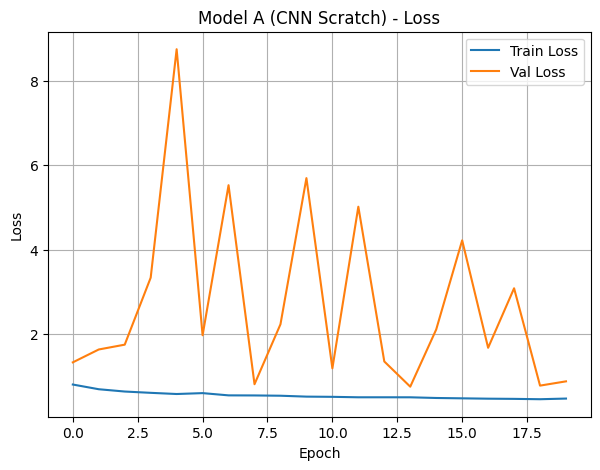

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Model A (CNN Scratch) - Accuracy')
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(7,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Model A (CNN Scratch) - Loss')
plt.legend(); plt.grid(True); plt.show()

===== MODEL A (CNN SCRATCH) TEST RESULTS =====
Test Accuracy: 0.7276
Test Loss: 0.8577

Classification Report:
              precision    recall  f1-score   support

   BACTERIAL       0.66      0.98      0.79       242
      NORMAL       0.95      0.57      0.71       234
       VIRAL       0.66      0.57      0.61       148

    accuracy                           0.73       624
   macro avg       0.76      0.71      0.70       624
weighted avg       0.77      0.73      0.72       624



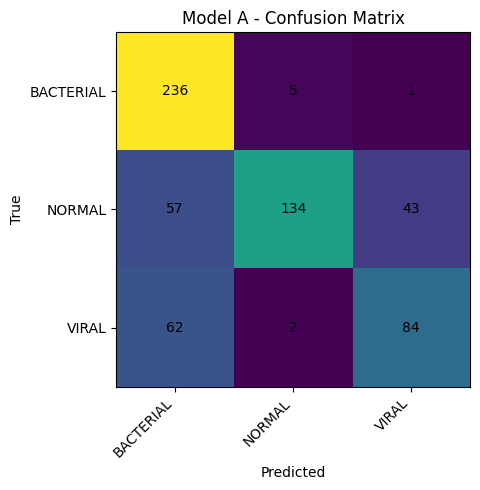

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Test evaluation
test_loss, test_acc = model_a.evaluate(test_generator, verbose=0)
print("===== MODEL A (CNN SCRATCH) TEST RESULTS =====")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print("=============================================")

# Predictions
y_prob = model_a.predict(test_generator, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_generator.classes

labels = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=labels))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Model A - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.yticks(range(len(labels)), labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

**EfficientNetB0** with ImageNet weights as a frozen backbone (feature extractor) and learns only a new classification head for the 3 X-ray classes, then reports the best validation performance and evaluates on the test set.

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
import numpy as np

# 1) Backbone pretrained
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
base_model.trainable = False  # B1: freeze all backbone

# 2) Head
inputs = tf.keras.Input(shape=(224,224,3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(3, activation="softmax")(x)

model_b = models.Model(inputs, outputs, name="EffNetB0_B1_Frozen")

# 3) Compile
model_b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# 4) Train or load
finetuned_path = os.path.join(BASE_SAVE_DIR, "model_b_finetuned.keras")
if os.path.exists(finetuned_path):
    print(f"Loading Model B from {finetuned_path}")
    model_b = tf.keras.models.load_model(finetuned_path)
    history_b1 = None
    history_b2 = None
else:
    EPOCHS_B1 = 15
    history_b1 = model_b.fit(
        train_generator,
        epochs=EPOCHS_B1,
        validation_data=val_generator
    )

# 5) Best VAL summary
best_epoch_b1 = int(np.argmax(history_b1.history["val_accuracy"]))
best_val_acc_b1 = float(history_b1.history["val_accuracy"][best_epoch_b1])
best_val_loss_b1 = float(history_b1.history["val_loss"][best_epoch_b1])

print("\n===== MODEL B1 (Frozen) SUMMARY =====")
print(f"Best epoch: {best_epoch_b1+1}")
print(f"Best Val Accuracy: {best_val_acc_b1:.4f}")
print(f"Val Loss at Best: {best_val_loss_b1:.4f}")
print("=====================================\n")

# 6) TEST
test_loss_b1, test_acc_b1 = model_b.evaluate(test_generator, verbose=0)
print("===== MODEL B1 TEST RESULTS =====")
print(f"Test Accuracy: {test_acc_b1:.4f}")
print(f"Test Loss: {test_loss_b1:.4f}")
print("=================================")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 146s 893ms/step - accuracy: 0.6093 - loss: 1.1771 - val_accuracy: 0.7450 - val_loss: 0.6413
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 83s 638ms/step - accuracy: 0.7222 - loss: 0.7024 - val_accuracy: 0.7488 - val_loss: 0.5606
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 84s 639ms/step - accuracy: 0.7664 - loss: 0.5862 - val_accuracy: 0.7498 - val_loss: 0.5516
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 83s 634ms/step - accuracy: 0.7736 - loss: 0.5335 - val_accuracy: 0.7546 - val_loss: 0.5598
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 84s 637ms/step - accuracy: 0.7646 - loss: 0.5460 - val_accuracy: 0.7440 - val_loss: 0.5615
Epoch 6/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 84s 638ms/step - accuracy: 0.7743 - loss: 0.5205 - val_accuracy: 0.7584 - val_loss: 0.5407
Epoch 7/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 83s 634ms/step - accuracy: 0.7990 - loss: 0.4699 - val_accuracy: 0.7661 - val_loss: 0.5134
Epoch 8/15
131/131 ━━━━━━━━━━━━

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Test evaluation
test_loss_b1_eval, test_acc_b1_eval = model_b.evaluate(test_generator, verbose=0)

# Predictions for confusion matrix
y_prob_b1 = model_b.predict(test_generator, verbose=0)
y_pred_b1 = np.argmax(y_prob_b1, axis=1)
y_true_b1 = test_generator.classes

labels_b1 = list(test_generator.class_indices.keys())

print("\nClassification Report (Model B1 - Frozen):")
print(classification_report(y_true_b1, y_pred_b1, target_names=labels_b1))

cm_b1 = confusion_matrix(y_true_b1, y_pred_b1)

plt.figure(figsize=(6,5))
plt.imshow(cm_b1)
plt.title("Model B1 (Frozen) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(labels_b1)), labels_b1, rotation=45, ha='right')
plt.yticks(range(len(labels_b1)), labels_b1)

for i in range(cm_b1.shape[0]):
    for j in range(cm_b1.shape[1]):
        plt.text(j, i, cm_b1[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


**partial fine-tuning** by unfreezing only the top ~30% of EfficientNetB0 layers (keeping lower layers frozen), recompiling with a very small learning rate, and training to adapt the pretrained features to the X-ray domain, then reporting best validation and test results.

In [ ]:
import numpy as np
import tensorflow as tf

# 1) Fine‑tuning
finetuned_path = os.path.join(BASE_SAVE_DIR, "model_b_finetuned.keras")
if not os.path.exists(finetuned_path):
    base_model.trainable = True

    # Release only top layers (leave lower layers frozen)
    fine_tune_at = int(len(base_model.layers) * 0.7)
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    print("Backbone layers:", len(base_model.layers))
    print("Fine-tune from layer:", fine_tune_at)

    # 2) Re-compile with small LR (mandatory after changing trainable)
    model_b.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    # 3) Train fine-tuning
    EPOCHS_B2 = 10
    history_b2 = model_b.fit(
        train_generator,
        epochs=EPOCHS_B2,
        validation_data=val_generator
    )

    # save the fine-tuned model for future runs
    model_b.save(finetuned_path)
    print(f"Saved fine-tuned model to {finetuned_path}")
else:
    print(f"Fine‑tuned model already exists at {finetuned_path}, skipping B2 training.")
    history_b2 = None

# 4) Best VAL summary
best_epoch_b2 = int(np.argmax(history_b2.history["val_accuracy"]))
best_val_acc_b2 = float(history_b2.history["val_accuracy"][best_epoch_b2])
best_val_loss_b2 = float(history_b2.history["val_loss"][best_epoch_b2])

print("\n===== MODEL B2 (Fine-Tuned) SUMMARY =====")
print(f"Best epoch: {best_epoch_b2+1}")
print(f"Best Val Accuracy: {best_val_acc_b2:.4f}")
print(f"Val Loss at Best: {best_val_loss_b2:.4f}")
print("=========================================\n")

# 5) TEST
test_loss_b2, test_acc_b2 = model_b.evaluate(test_generator, verbose=0)
print("===== MODEL B2 TEST RESULTS =====")
print(f"Test Accuracy: {test_acc_b2:.4f}")
print(f"Test Loss: {test_loss_b2:.4f}")
print("=================================")

Backbone layers: 238
Fine-tune from layer: 166
Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 148s 859ms/step - accuracy: 0.6757 - loss: 0.7263 - val_accuracy: 0.7584 - val_loss: 0.5685
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 86s 656ms/step - accuracy: 0.7406 - loss: 0.6231 - val_accuracy: 0.7613 - val_loss: 0.5559
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 86s 654ms/step - accuracy: 0.7537 - loss: 0.5735 - val_accuracy: 0.7632 - val_loss: 0.5326
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 85s 650ms/step - accuracy: 0.7684 - loss: 0.5584 - val_accuracy: 0.7728 - val_loss: 0.5205
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 85s 652ms/step - accuracy: 0.7856 - loss: 0.5121 - val_accuracy: 0.7747 - val_loss: 0.5199
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 85s 651ms/step - accuracy: 0.7858 - loss: 0.4981 - val_accuracy: 0.7776 - val_loss: 0.5121
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 85s 651ms/step - accuracy: 0.7874 - loss: 0.4992 - val_accuracy: 0.7824 - val_loss: 0.5081
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Predictions for confusion matrix (B2)
y_prob_b2 = model_b.predict(test_generator, verbose=0)
y_pred_b2 = np.argmax(y_prob_b2, axis=1)
y_true_b2 = test_generator.classes

labels_b2 = list(test_generator.class_indices.keys())

print("\nClassification Report (Model B2 - Fine-tuned):")
print(classification_report(y_true_b2, y_pred_b2, target_names=labels_b2))

cm_b2 = confusion_matrix(y_true_b2, y_pred_b2)

plt.figure(figsize=(6,5))
plt.imshow(cm_b2)
plt.title("Model B2 (Fine-tuned) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(labels_b2)), labels_b2, rotation=45, ha='right')
plt.yticks(range(len(labels_b2)), labels_b2)

for i in range(cm_b2.shape[0]):
    for j in range(cm_b2.shape[1]):
        plt.text(j, i, cm_b2[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


**patch-based sequence model**: each image is split into 16×16 patches (tokens), projected into an embedding space, and then a GRU processes the token sequence to predict the 3 X-ray classes, with validation and test evaluation reported at the end.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

IMG_H, IMG_W = 224, 224
PATCH = 16
NUM_PATCHES = (IMG_H // PATCH) * (IMG_W // PATCH)  # 14*14=196
PATCH_DIM = PATCH * PATCH * 3                      # 16*16*3=768
EMB_DIM = 128

# 1) Patchify layer
class Patchify(layers.Layer):
    def __init__(self, patch_size=16, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID"
        )
        # (B, 14, 14, 768) -> (B, 196, 768)
        batch = tf.shape(images)[0]
        patches = tf.reshape(patches, [batch, -1, patches.shape[-1]])
        return patches

# 2) Model
inputs = layers.Input(shape=(224,224,3))
x = Patchify(PATCH)(inputs)                      # (B, 196, 768)
x = layers.Dense(EMB_DIM)(x)                     # token embedding
x = layers.LayerNormalization()(x)

# RNN over tokens
x = layers.GRU(128, return_sequences=False)(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(3, activation="softmax")(x)

model_c = models.Model(inputs, outputs, name="Patch_RNN_GRU")

model_c.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_c_path = os.path.join(BASE_SAVE_DIR, "model_C_patch_rnn.keras")
if os.path.exists(model_c_path):
    print(f"Loading Model C from {model_c_path}")
    model_c = tf.keras.models.load_model(model_c_path, custom_objects={"Patchify": Patchify})
    history_c = None
    test_loss_c, test_acc_c = model_c.evaluate(test_generator, verbose=0)
    print("\n===== MODEL C (Patch-RNN) - LOADED =====")
    print(f"Test Accuracy: {test_acc_c:.4f}")
    print(f"Test Loss: {test_loss_c:.4f}")
    print("=======================================\n")
else:
    EPOCHS_C = 15
    history_c = model_c.fit(
        train_generator,
        epochs=EPOCHS_C,
        validation_data=val_generator
    )

    best_epoch_c = int(np.argmax(history_c.history["val_accuracy"]))
    print("\n===== MODEL C (Patch-RNN) SUMMARY =====")
    print(f"Best epoch: {best_epoch_c+1}")
    print(f"Best Val Accuracy: {float(history_c.history['val_accuracy'][best_epoch_c]):.4f}")
    print("=======================================\n")

    test_loss_c, test_acc_c = model_c.evaluate(test_generator, verbose=0)
    print("===== MODEL C TEST RESULTS =====")
    print(f"Test Accuracy: {test_acc_c:.4f}")
    print(f"Test Loss: {test_loss_c:.4f}")
    print("================================")

Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 88s 635ms/step - accuracy: 0.4934 - loss: 1.0815 - val_accuracy: 0.5225 - val_loss: 1.0115
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 82s 627ms/step - accuracy: 0.5775 - loss: 0.9476 - val_accuracy: 0.5494 - val_loss: 0.9614
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 81s 619ms/step - accuracy: 0.6003 - loss: 0.9045 - val_accuracy: 0.5925 - val_loss: 0.9311
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 82s 630ms/step - accuracy: 0.6162 - loss: 0.8698 - val_accuracy: 0.5839 - val_loss: 0.9218
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 81s 622ms/step - accuracy: 0.6347 - loss: 0.8573 - val_accuracy: 0.5801 - val_loss: 0.9179
Epoch 6/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 82s 624ms/step - accuracy: 0.6342 - loss: 0.8495 - val_accuracy: 0.5810 - val_loss: 0.9326
Epoch 7/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 81s 622ms/step - accuracy: 0.6411 - loss: 0.8387 - val_accuracy: 0.5954 - val_loss: 0.9494
Epoch 8/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 84s 641ms/step - accuracy: 0.6397 - loss: 0

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Predictions for confusion matrix (Model C)
y_prob_c = model_c.predict(test_generator, verbose=0)
y_pred_c = np.argmax(y_prob_c, axis=1)
y_true_c = test_generator.classes

labels_c = list(test_generator.class_indices.keys())

print("\nClassification Report (Model C - Patch-RNN):")
print(classification_report(y_true_c, y_pred_c, target_names=labels_c))

cm_c = confusion_matrix(y_true_c, y_pred_c)

plt.figure(figsize=(6,5))
plt.imshow(cm_c)
plt.title("Model C (Patch-RNN) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(labels_c)), labels_c, rotation=45, ha='right')
plt.yticks(range(len(labels_c)), labels_c)

for i in range(cm_c.shape[0]):
    for j in range(cm_c.shape[1]):
        plt.text(j, i, cm_c[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


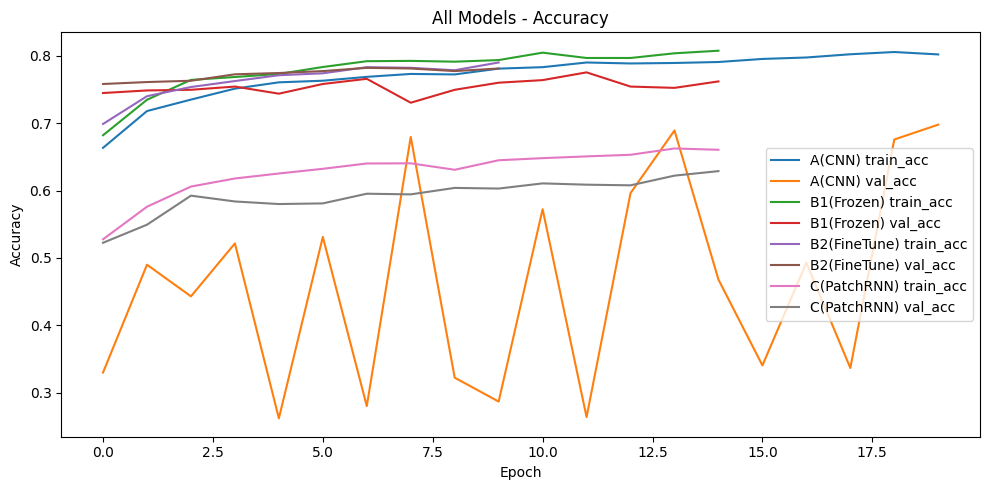

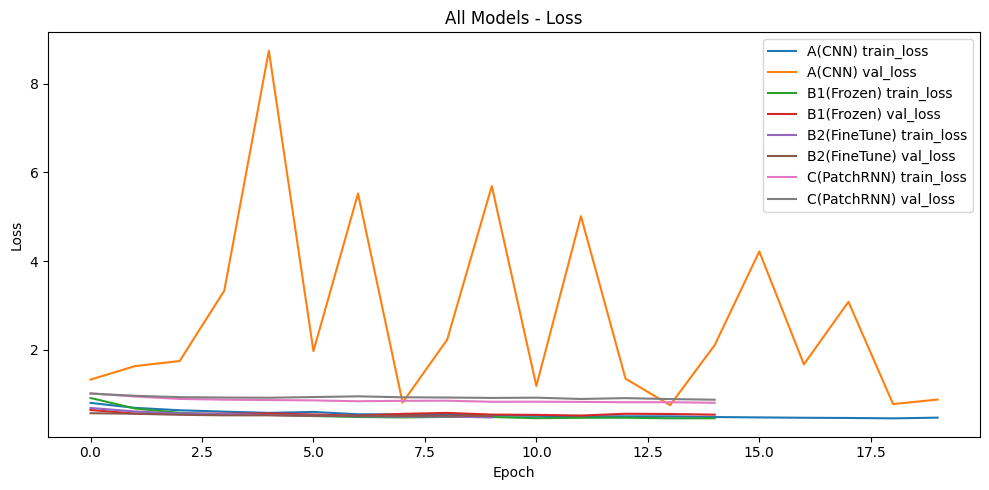

In [ ]:
import matplotlib.pyplot as plt

def plot_all_histories(histories, labels):
    # ---- Accuracy (one figure) ----
    plt.figure(figsize=(10,5))
    for h, lab in zip(histories, labels):
        plt.plot(h.history["accuracy"], label=f"{lab} train_acc")
        plt.plot(h.history["val_accuracy"], label=f"{lab} val_acc")
    plt.title("All Models - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---- Loss (one figure) ----
    plt.figure(figsize=(10,5))
    for h, lab in zip(histories, labels):
        plt.plot(h.history["loss"], label=f"{lab} train_loss")
        plt.plot(h.history["val_loss"], label=f"{lab} val_loss")
    plt.title("All Models - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ---- call with your histories ----
histories = [history, history_b1, history_b2, history_c]
labels = ["A(CNN)", "B1(Frozen)", "B2(FineTune)", "C(PatchRNN)"]

plot_all_histories(histories, labels)

In [ ]:
import numpy as np
import pandas as pd

def summarize_model(name, history_obj, model_obj, test_gen):
    # Best val epoch
    best_epoch = int(np.argmax(history_obj.history["val_accuracy"]))
    best_val_acc = float(history_obj.history["val_accuracy"][best_epoch])
    best_val_loss = float(history_obj.history["val_loss"][best_epoch])

    # Test metrics
    test_loss, test_acc = model_obj.evaluate(test_gen, verbose=0)

    return {
        "Model": name,
        "Best Epoch (val_acc)": best_epoch + 1,
        "Best Val Acc": round(best_val_acc, 4),
        "Val Loss @ Best": round(best_val_loss, 4),
        "Test Acc": round(float(test_acc), 4),
        "Test Loss": round(float(test_loss), 4)
    }

results = []

# ---- A ----
results.append(summarize_model("A - CNN Scratch", history, model_a, test_generator))

# ---- B1 ----
results.append(summarize_model("B1 - EffNet Frozen", history_b1, model_b, test_generator))

# ---- B2 ----
results.append(summarize_model("B2 - EffNet FineTune", history_b2, model_b, test_generator))

# ---- C ----
results.append(summarize_model("C - Patch RNN", history_c, model_c, test_generator))

df = pd.DataFrame(results)

# Sort by Best Val Acc (academic selection)
df_sorted = df.sort_values(by="Best Val Acc", ascending=False).reset_index(drop=True)

print("\n===== MODEL COMPARISON TABLE (sorted by Best Val Acc) =====\n")
display(df_sorted)

best_model_row = df_sorted.iloc[0]
print("\n Best model by Validation Accuracy:")
print(best_model_row.to_dict())


===== MODEL COMPARISON TABLE (sorted by Best Val Acc) =====



,Model,Best Epoch (val_acc),Best Val Acc,Val Loss @ Best,Test Acc,Test Loss
0,B2 - EffNet FineTune,7,0.7824,0.5081,0.7949,0.7139
1,B1 - EffNet Frozen,12,0.7756,0.5158,0.7949,0.7139
2,A - CNN Scratch,20,0.6980,0.8763,0.7276,0.8577
3,C - Patch RNN,15,0.6290,0.8728,0.6074,1.0174



 Best model by Validation Accuracy:
{'Model': 'B2 - EffNet FineTune', 'Best Epoch (val_acc)': 7, 'Best Val Acc': 0.7824, 'Val Loss @ Best': 0.5081, 'Test Acc': 0.7949, 'Test Loss': 0.7139}


**Save the best model**

In [ ]:
import json

BEST_MODEL_PATH = os.path.join(BASE_SAVE_DIR, "best_model.keras")
LABELS_PATH = os.path.join(BASE_SAVE_DIR, "class_indices.json")

# Save model
model_b.save(BEST_MODEL_PATH)
print(f"Saved best model to: {BEST_MODEL_PATH}")

# Save class indices (for correct decoding later)
with open(LABELS_PATH, "w") as f:
    json.dump(train_generator.class_indices, f, indent=2)
print(f"Saved class indices to: {LABELS_PATH}")
print("class_indices:", train_generator.class_indices)

✅ Saved best model to: best_model.keras
✅ Saved class indices to: class_indices.json
class_indices: {'BACTERIAL': 0, 'NORMAL': 1, 'VIRAL': 2}


In [ ]:
import tensorflow as tf
import numpy as np
import json
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

MODEL_PATH = os.path.join(BASE_SAVE_DIR, "best_model.keras")
LABELS_PATH = os.path.join(BASE_SAVE_DIR, "class_indices.json")
IMG_SIZE = (224, 224)

# Load model
model_test = tf.keras.models.load_model(MODEL_PATH)

# Load labels
with open(LABELS_PATH, "r") as f:
    class_indices = json.load(f)

idx_to_label = {v: k for k, v in class_indices.items()}
print("Loaded model + labels:", idx_to_label)

def predict_xray(img_path, show_image=True):
    # Load + resize
    img = image.load_img(img_path, target_size=IMG_SIZE)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    # Preprocess (same as training)
    x = preprocess_input(x)

    # Predict
    probs = model_test.predict(x, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_label = idx_to_label[pred_idx]

    if show_image:
        plt.figure()
        plt.imshow(img, cmap="gray")
        plt.axis("off")
        plt.title(f"Prediction: {pred_label} | prob={probs[pred_idx]:.3f}")
        plt.show()

    # Print probabilities
    print("Probabilities:")
    for i in range(len(probs)):
        print(f"  {idx_to_label[i]:9s}: {probs[i]:.4f}")

    return pred_label, probs

✅ Loaded model + labels: {0: 'BACTERIAL', 1: 'NORMAL', 2: 'VIRAL'}


Saving IM-0001-0001.jpeg to IM-0001-0001.jpeg


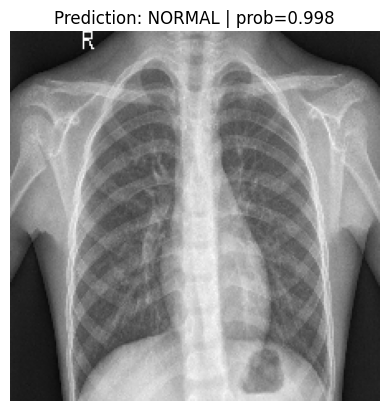

Probabilities:
  BACTERIAL: 0.0005
  NORMAL   : 0.9978
  VIRAL    : 0.0017

✅ Final prediction: NORMAL


In [ ]:
from google.colab import files

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

pred_label, probs = predict_xray(img_path, show_image=True)
print("\nFinal prediction:", pred_label)

**Save model A and C**

In [ ]:
import json

# Save A
path_a = os.path.join(BASE_SAVE_DIR, "model_A_cnn.keras")
model_a.save(path_a)
print(f"Saved: {path_a}")

# Save C
path_c = os.path.join(BASE_SAVE_DIR, "model_C_patch_rnn.keras")
model_c.save(path_c)
print(f"Saved: {path_c}")

# Save labels once
labels_path = os.path.join(BASE_SAVE_DIR, "class_indices.json")
with open(labels_path, "w") as f:
    json.dump(train_generator.class_indices, f, indent=2)
print(f"Saved: {labels_path}")
print("class_indices:", train_generator.class_indices)

✅ Saved: model_A_cnn.keras
✅ Saved: model_C_patch_rnn.keras
✅ Saved: class_indices.json
class_indices: {'BACTERIAL': 0, 'NORMAL': 1, 'VIRAL': 2}


✅ Loaded models A and C
✅ Labels: {0: 'BACTERIAL', 1: 'NORMAL', 2: 'VIRAL'}


Saving IM-0001-0001.jpeg to IM-0001-0001 (1).jpeg


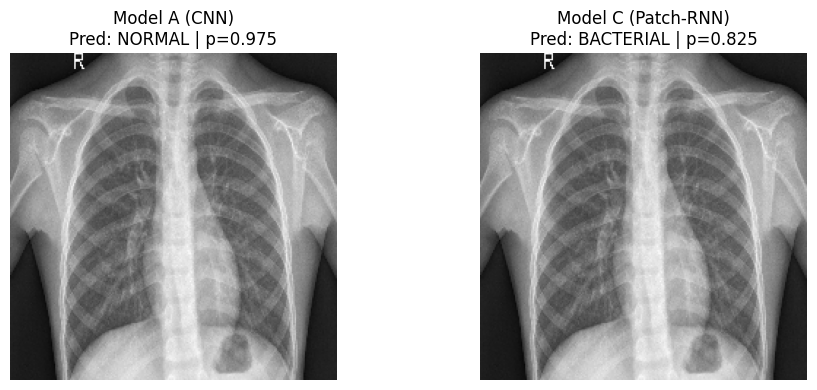


=== Probabilities Comparison (A vs C) ===
BACTERIAL | A: 0.0197  | C: 0.8249
NORMAL    | A: 0.9752  | C: 0.0213
VIRAL     | A: 0.0051  | C: 0.1538

✅ Final Predictions:
Model A: NORMAL
Model C: BACTERIAL


In [ ]:
import tensorflow as tf
import numpy as np
import json
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras import layers

IMG_SIZE = (224, 224)

MODEL_A_PATH = os.path.join(BASE_SAVE_DIR, "model_A_cnn.keras")
MODEL_C_PATH = os.path.join(BASE_SAVE_DIR, "model_C_patch_rnn.keras")
LABELS_PATH  = os.path.join(BASE_SAVE_DIR, "class_indices.json")

# ---- Define Patchify again (needed for loading Model C) ----
class Patchify(layers.Layer):
    def __init__(self, patch_size=16, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID"
        )
        batch = tf.shape(images)[0]
        patches = tf.reshape(patches, [batch, -1, patches.shape[-1]])
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config

# ---- Load labels ----
with open(LABELS_PATH, "r") as f:
    class_indices = json.load(f)
idx_to_label = {v: k for k, v in class_indices.items()}

# ---- Load models ----
model_A = tf.keras.models.load_model(MODEL_A_PATH)
model_C = tf.keras.models.load_model(MODEL_C_PATH, custom_objects={"Patchify": Patchify})

print("Loaded models A and C")
print("Labels:", idx_to_label)

# ---- Upload image once ----
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ---- Preprocess ----
img = image.load_img(img_path, target_size=IMG_SIZE)
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# ---- Predict ----
probs_A = model_A.predict(x, verbose=0)[0]
probs_C = model_C.predict(x, verbose=0)[0]

pred_A = idx_to_label[int(np.argmax(probs_A))]
pred_C = idx_to_label[int(np.argmax(probs_C))]

# ---- Show side-by-side ----
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title(f"Model A (CNN)\nPred: {pred_A} | p={probs_A[np.argmax(probs_A)]:.3f}")

plt.subplot(1,2,2)
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title(f"Model C (Patch-RNN)\nPred: {pred_C} | p={probs_C[np.argmax(probs_C)]:.3f}")

plt.tight_layout()
plt.show()

print("\n=== Probabilities Comparison (A vs C) ===")
for i in range(len(idx_to_label)):
    label = idx_to_label[i]
    print(f"{label:9s} | A: {probs_A[i]:.4f}  | C: {probs_C[i]:.4f}")

print("\nFinal Predictions:")
print("Model A:", pred_A)
print("Model C:", pred_C)